## Connect mysql database to python

In [ ]:
import mysql.connector
import pandas as pd
from mysql.connector import Error

try:
    connection =mysql.connector.connect (  
        host= '<your_host>',          # 'localhost'
        database= '<your_database>',  #'HR_Analysis'
        user= '<your_username>',      #  'root'
        password = '<your_password>'   #  password here
    )

    if connection.is_connected():
        print("Connected to MySQL database")

except Error as e:
    print("Error while connecting to MySQL", e)


Connected to MySQL database


In [2]:
query = "SELECT * FROM employees"
df = pd.read_sql(query, connection)

C:\Users\SIGMA\AppData\Local\Temp\ipykernel_3668\3462241998.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


## Inspect data

In [3]:
df.head()

,employee_id,first_name,last_name,gender,state,city,education_level,birthdate,hiredate,termdate,department,job_title,salary,performance_rating
0,00-10001272,Samuel,Burgess,Female,West Virginia,Huntington,Bachelor,1975-01-11,2018-10-30,None,Customer Service,Help Desk Technician,66787.0,Satisfactory\r
1,00-10006914,Ethan,Case,Male,Michigan,Detroit,High School,1980-09-24,2022-10-12,None,Operations,Inventory Specialist,63874.0,Needs Improvement\r
2,00-10008169,Barbara,Blair,Male,Michigan,Warren,Bachelor,1959-07-28,2022-11-23,None,Operations,Operations Analyst,88579.0,Good\r
3,00-10012470,Amy,Davidson,Female,Michigan,Grand Rapids,Bachelor,1989-02-23,2019-10-15,None,Finance,Accountant,62543.0,Good\r
4,00-10017850,Ricky,Serrano,Male,New York,New York City,Bachelor,2000-09-18,2016-10-07,None,Sales,Sales Specialist,92123.0,Good\r


In [4]:
## number of all employees recorded in data not in company now
total_employees = len(df)
print(total_employees)

8950


In [5]:
df.columns

Index(['employee_id', 'first_name', 'last_name', 'gender', 'state', 'city',
       'education_level', 'birthdate', 'hiredate', 'termdate', 'department',
       'job_title', 'salary', 'performance_rating'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         8950 non-null   object 
 1   first_name          8950 non-null   object 
 2   last_name           8950 non-null   object 
 3   gender              8950 non-null   object 
 4   state               8950 non-null   object 
 5   city                8950 non-null   object 
 6   education_level     8950 non-null   object 
 7   birthdate           8950 non-null   object 
 8   hiredate            8950 non-null   object 
 9   termdate            966 non-null    object 
 10  department          8950 non-null   object 
 11  job_title           8950 non-null   object 
 12  salary              8950 non-null   float64
 13  performance_rating  8950 non-null   object 
dtypes: float64(1), object(13)
memory usage: 979.0+ KB


In [7]:
df.describe()

,salary
count,8950.000000
mean,70964.213520
std,13763.126237
min,51835.000000
25%,60920.500000
50%,66592.500000
75%,78600.500000
max,149377.000000


In [8]:
df.describe(include='object')

,employee_id,first_name,last_name,gender,state,city,education_level,birthdate,hiredate,termdate,department,job_title,performance_rating
count,8950,8950,8950,8950,8950,8950,8950,8950,8950,966,8950,8950,8950
unique,8950,649,975,2,8,24,4,6786,3192,805,7,28,4
top,00-99996378,Michael,Smith,Male,New York,New York City,Bachelor,1986-05-26,2017-11-02,2023-12-11,Operations,Logistics Coordinator,Good\r
freq,1,196,180,4801,6270,2959,5416,6,12,4,2718,1061,3763


In [9]:
## number of employees that are active and ex 
active_count = df['termdate'].isna().sum()
ex_count = df['termdate'].notna().sum()
print("Active employees:", active_count)
print("Ex-employees:", ex_count)

Active employees: 7984
Ex-employees: 966


## Data cleaning and transformation

In [10]:
df['full_name'] = df['first_name'] + [" "] + df['last_name']

In [11]:
df = df.drop(columns=['first_name','last_name'])

In [12]:
df['status'] = df['termdate'].apply(lambda x: 'Active' if pd.isna(x) else 'Terminated')

In [13]:
from datetime import datetime
df['age'] = df['birthdate'].apply(lambda x: datetime.now().year - x.year if pd.notnull(x) else None)
df.head()

,employee_id,gender,state,city,education_level,birthdate,hiredate,termdate,department,job_title,salary,performance_rating,full_name,status,age
0,00-10001272,Female,West Virginia,Huntington,Bachelor,1975-01-11,2018-10-30,None,Customer Service,Help Desk Technician,66787.0,Satisfactory\r,Samuel Burgess,Active,51
1,00-10006914,Male,Michigan,Detroit,High School,1980-09-24,2022-10-12,None,Operations,Inventory Specialist,63874.0,Needs Improvement\r,Ethan Case,Active,46
2,00-10008169,Male,Michigan,Warren,Bachelor,1959-07-28,2022-11-23,None,Operations,Operations Analyst,88579.0,Good\r,Barbara Blair,Active,67
3,00-10012470,Female,Michigan,Grand Rapids,Bachelor,1989-02-23,2019-10-15,None,Finance,Accountant,62543.0,Good\r,Amy Davidson,Active,37
4,00-10017850,Male,New York,New York City,Bachelor,2000-09-18,2016-10-07,None,Sales,Sales Specialist,92123.0,Good\r,Ricky Serrano,Active,26


In [14]:
df.columns

Index(['employee_id', 'gender', 'state', 'city', 'education_level',
       'birthdate', 'hiredate', 'termdate', 'department', 'job_title',
       'salary', 'performance_rating', 'full_name', 'status', 'age'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         8950 non-null   object 
 1   gender              8950 non-null   object 
 2   state               8950 non-null   object 
 3   city                8950 non-null   object 
 4   education_level     8950 non-null   object 
 5   birthdate           8950 non-null   object 
 6   hiredate            8950 non-null   object 
 7   termdate            966 non-null    object 
 8   department          8950 non-null   object 
 9   job_title           8950 non-null   object 
 10  salary              8950 non-null   float64
 11  performance_rating  8950 non-null   object 
 12  full_name           8950 non-null   object 
 13  status              8950 non-null   object 
 14  age                 8950 non-null   int64  
dtypes: float64(1), int64(1), object(13)
memory usage: 1.0+ 

## EDA for data

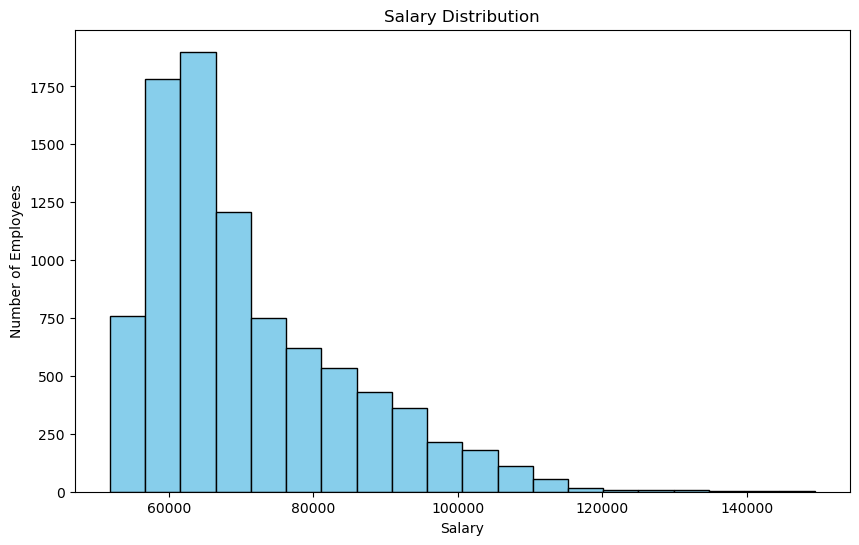

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.hist(df['salary'], bins=20, color='skyblue', edgecolor='black')
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.show()


In [17]:
# average salary by department
avg_salary_dept = df.groupby('department')['salary'].mean().sort_values(ascending=False)
print("\nAverage salary per department:")
print(round(avg_salary_dept, 2))
max_dept = avg_salary_dept.idxmax()
max_value = avg_salary_dept.max()
min_dept = avg_salary_dept.idxmin()
min_value = avg_salary_dept.min()
print(f"\nMax average salary per department: {round(max_value, 2)} (Department: {max_dept})")
print(f"Min average salary per department: {round(min_value, 2)} (Department: {min_dept})")



Average salary per department:
department
IT                  81925.61
Finance             76451.14
Sales               76204.95
Marketing           67659.02
Customer Service    65837.73
Operations          65400.25
HR                  64145.03
Name: salary, dtype: float64

Max average salary per department: 81925.61 (Department: IT)
Min average salary per department: 64145.03 (Department: HR)


In [18]:
df.gender.value_counts()

gender
Male      4801
Female    4149
Name: count, dtype: int64

In [19]:
# Maximum salary per department
max_salary_dept = df.groupby('department')['salary'].max()
print("\nMax salary per department:")
print(max_salary_dept)

# Minimum salary per department
min_salary_dept = df.groupby('department')['salary'].min()
print("\nMin salary per department:")
print(min_salary_dept)



Max salary per department:
department
Customer Service    104359.0
Finance             149377.0
HR                   82203.0
IT                  133425.0
Marketing           110729.0
Operations          115534.0
Sales               135055.0
Name: salary, dtype: float64

Min salary per department:
department
Customer Service    51835.0
Finance             51887.0
HR                  52401.0
IT                  52103.0
Marketing           51887.0
Operations          52138.0
Sales               51865.0
Name: salary, dtype: float64


In [20]:
# Maximum salary per job_title
max_salary_dept = df.groupby('job_title')['salary'].max()
print("\nMax salary per job_title:")
print(max_salary_dept.head())
print("============================")
min_salary_dept = df.groupby('job_title')['salary'].min()
print("\Min salary per job_title:")
print(min_salary_dept.head())


Max salary per job_title:
job_title
Accountant                         101461.0
Accounts Payable Specialist         78235.0
Content Creator                     73603.0
Customer Service Manager           104359.0
Customer Service Representative     74864.0
Name: salary, dtype: float64
\Min salary per job_title:
job_title
Accountant                         51887.0
Accounts Payable Specialist        53141.0
Content Creator                    51887.0
Customer Service Manager           67027.0
Customer Service Representative    52326.0
Name: salary, dtype: float64


<>:7: SyntaxWarning: invalid escape sequence '\M'
<>:7: SyntaxWarning: invalid escape sequence '\M'
C:\Users\SIGMA\AppData\Local\Temp\ipykernel_3668\165049092.py:7: SyntaxWarning: invalid escape sequence '\M'
  print("\Min salary per job_title:")


In [21]:
## to know info about who take max salary 
max_salary_row = df.loc[df['salary'].idxmax()]
print("Employee with maximum salary:")
max_salary_row[['full_name', 'department','job_title','salary']]

Employee with maximum salary:


full_name     Kristina Gardner
department             Finance
job_title      Finance Manager
salary                149377.0
Name: 6979, dtype: object

In [22]:
## to know info about who take min salary 
min_salary_row = df.loc[df['salary'].idxmin()]
print("\nEmployee with minimum salary:")
min_salary_row[['full_name', 'department','job_title', 'salary']]


Employee with minimum salary:


full_name          Joseph Mckinney
department        Customer Service
job_title     Help Desk Technician
salary                     51835.0
Name: 6115, dtype: object

In [23]:
# average salary by education
avg_salary_edu = df.groupby('education_level')['salary'].mean().sort_values(ascending=False)
print("\nAverage salary per education:")
print(round(avg_salary_edu, 2))
max_edu = avg_salary_edu.idxmax()
max_value = avg_salary_edu.max()
min_edu = avg_salary_edu.idxmin()
min_value = avg_salary_edu.min()
print(f"\nMax average salary per education: {round(max_value, 2)} (Level: {max_edu})")
print(f"Min average salary per education: {round(min_value, 2)} (Level: {min_edu})")


Average salary per education:
education_level
PhD            86033.20
Master         82675.96
Bachelor       69921.57
High School    62144.29
Name: salary, dtype: float64

Max average salary per education: 86033.2 (Level: PhD)
Min average salary per education: 62144.29 (Level: High School)


C:\Users\SIGMA\AppData\Local\Temp\ipykernel_3668\1591682482.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_salary_plot.index, y=avg_salary_plot.values, palette='viridis')


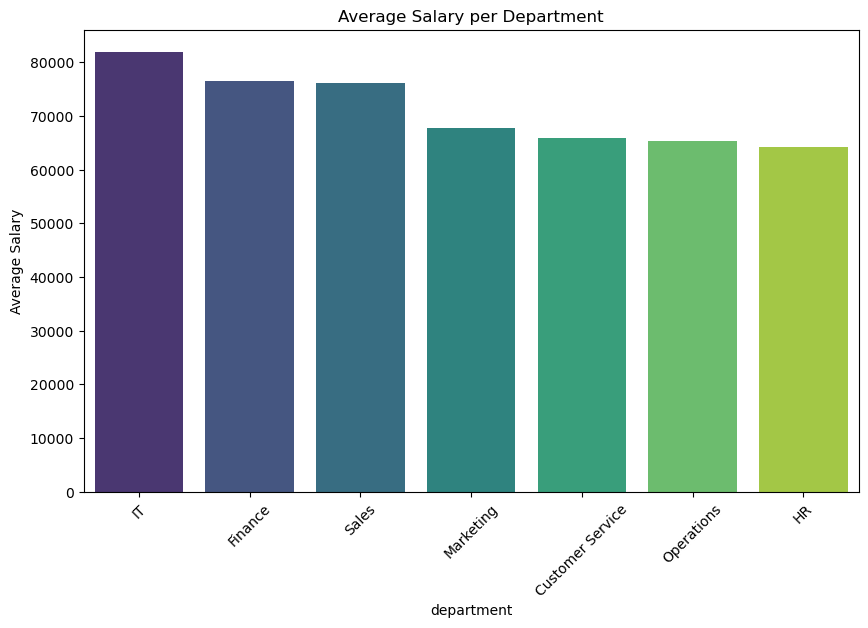

In [24]:
import seaborn as sns 
# Average salary per department
plt.figure(figsize=(10,6))
avg_salary_plot = df.groupby('department')['salary'].mean().sort_values(ascending=False)
sns.barplot(x=avg_salary_plot.index, y=avg_salary_plot.values, palette='viridis')
plt.title("Average Salary per Department")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)
plt.show()

C:\Users\SIGMA\AppData\Local\Temp\ipykernel_3668\3554230958.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_counts.index, y=dept_counts.values, palette='magma')


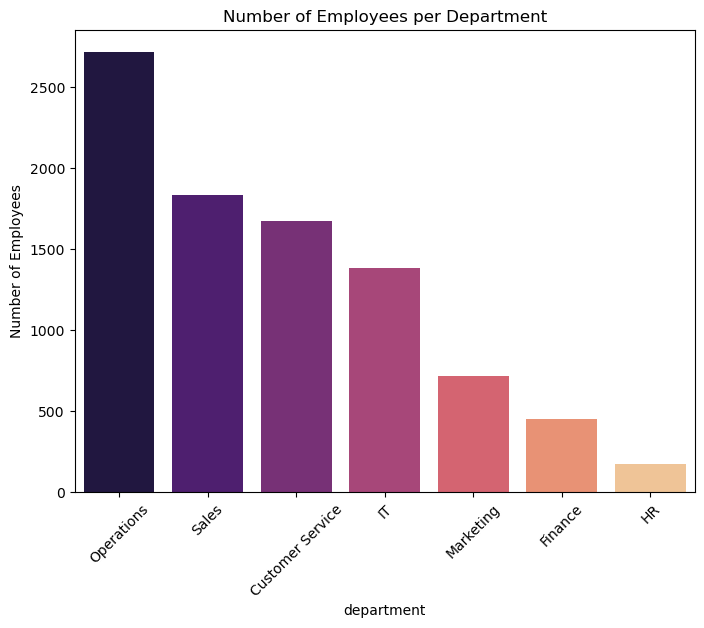

In [25]:
#  Number of employees per department
plt.figure(figsize=(8,6))
dept_counts = df['department'].value_counts()
sns.barplot(x=dept_counts.index, y=dept_counts.values, palette='magma')
plt.title("Number of Employees per Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.show()


C:\Users\SIGMA\AppData\Local\Temp\ipykernel_3668\3800887855.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perf_counts.index, y=perf_counts.values, palette='coolwarm')
) missing from font(s) DejaVu Sans.on\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


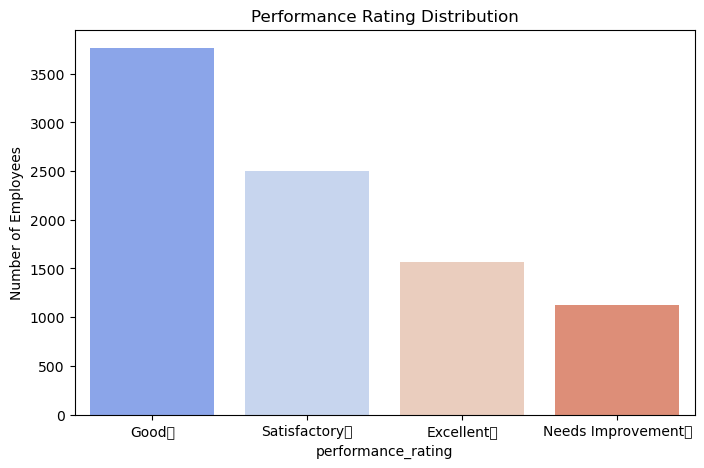

In [26]:

# Performance rating distribution
plt.figure(figsize=(8,5))
perf_counts = df['performance_rating'].value_counts()
sns.barplot(x=perf_counts.index, y=perf_counts.values, palette='coolwarm')
plt.title("Performance Rating Distribution")
plt.ylabel("Number of Employees")
plt.show()


C:\Users\SIGMA\AppData\Local\Temp\ipykernel_3668\2456657243.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='department', y='salary', data=df, palette='Set2')


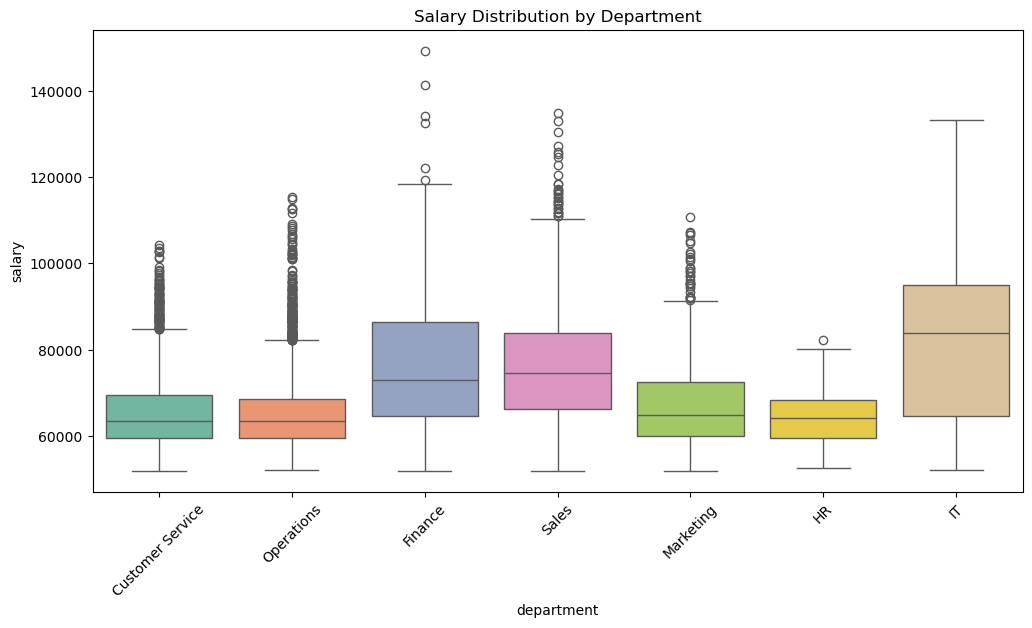

In [27]:
# e) Salary boxplot by department
plt.figure(figsize=(12,6))
sns.boxplot(x='department', y='salary', data=df, palette='Set2')
plt.title("Salary Distribution by Department")
plt.xticks(rotation=45)
plt.show()


In [28]:
df['performance_rating'].value_counts()

performance_rating
Good\r                 3763
Satisfactory\r         2498
Excellent\r            1566
Needs Improvement\r    1123
Name: count, dtype: int64

In [29]:
df['performance_rating'] = df['performance_rating'].str.replace('\r', '', regex=False)
df['performance_rating'].value_counts()

performance_rating
Good                 3763
Satisfactory         2498
Excellent            1566
Needs Improvement    1123
Name: count, dtype: int64

C:\Users\SIGMA\AppData\Local\Temp\ipykernel_3668\2883200882.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index,y=rating_counts.values,palette='Reds_r')


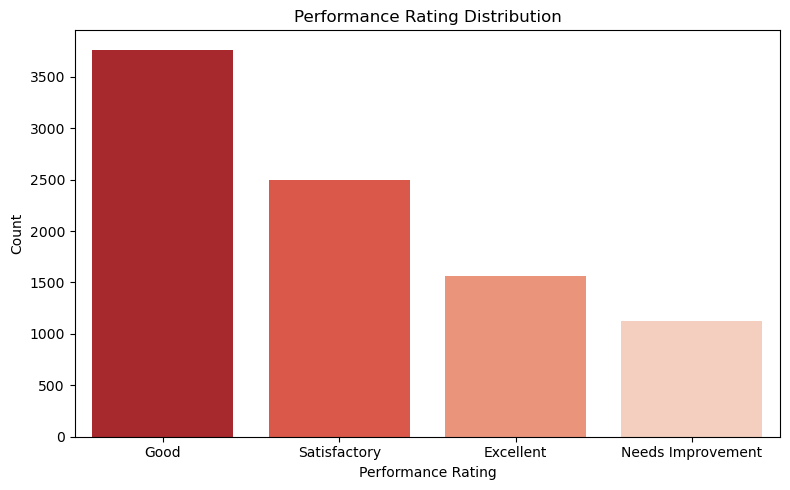

In [30]:
rating_counts = df['performance_rating'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=rating_counts.index,y=rating_counts.values,palette='Reds_r')
plt.title("Performance Rating Distribution")
plt.xlabel("Performance Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [31]:
df['performance_rating'].unique()

array(['Satisfactory', 'Needs Improvement', 'Good', 'Excellent'],
      dtype=object)

In [32]:
needs_improve= df[df['performance_rating'] == 'Needs Improvement']
print(len(needs_improve))
needs_improve.head()


1123


,employee_id,gender,state,city,education_level,birthdate,hiredate,termdate,department,job_title,salary,performance_rating,full_name,status,age
1,00-10006914,Male,Michigan,Detroit,High School,1980-09-24,2022-10-12,None,Operations,Inventory Specialist,63874.0,Needs Improvement,Ethan Case,Active,46
13,00-10137666,Female,New York,Buffalo,Bachelor,1977-03-16,2021-04-18,None,Marketing,Marketing Coordinator,75028.0,Needs Improvement,Ralph Sanford,Active,49
14,00-10146265,Female,New York,New York City,Bachelor,1982-10-14,2017-06-29,None,Finance,Accountant,68161.0,Needs Improvement,Melanie Rodriguez,Active,44
41,00-10392185,Male,North Carolina,Raleigh,High School,1977-12-27,2016-03-09,None,Customer Service,Customer Service Representative,59847.0,Needs Improvement,Sherry Carpenter,Active,49
44,00-10409797,Male,Michigan,Grand Rapids,High School,1997-05-15,2018-12-21,None,Customer Service,Help Desk Technician,57046.0,Needs Improvement,Gloria Hale,Active,29


In [33]:
needs_improve.groupby('gender')['performance_rating'].count()

gender
Female    535
Male      588
Name: performance_rating, dtype: int64

In [34]:
needs_improve.groupby('department')['performance_rating'].count()

department
Customer Service    329
Finance              39
HR                   23
IT                  158
Marketing           124
Operations          322
Sales               128
Name: performance_rating, dtype: int64

In [35]:
needs_improve.groupby('job_title')['performance_rating'].count().sort_values(ascending=False)

job_title
Inventory Specialist               219
Customer Service Representative    116
Support Specialist                 111
Help Desk Technician                99
IT Support Specialist               98
Logistics Coordinator               78
Content Creator                     64
Sales Representative                50
Software Developer                  41
SEO Specialist                      40
Sales Specialist                    38
Sales Consultant                    33
Operations Analyst                  23
System Administrator                19
Accountant                          19
Recruiter                           16
Marketing Coordinator               15
Accounts Payable Specialist         11
Financial Analyst                    9
Sales Manager                        7
HR Coordinator                       5
Marketing Manager                    5
Customer Service Manager             3
HR Assistant                         2
Operations Manager                   2
Name: performan

C:\Users\SIGMA\AppData\Local\Temp\ipykernel_3668\671072340.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='department', data=needs_improve, palette='Reds_r', order=needs_improve['department'].value_counts().index)


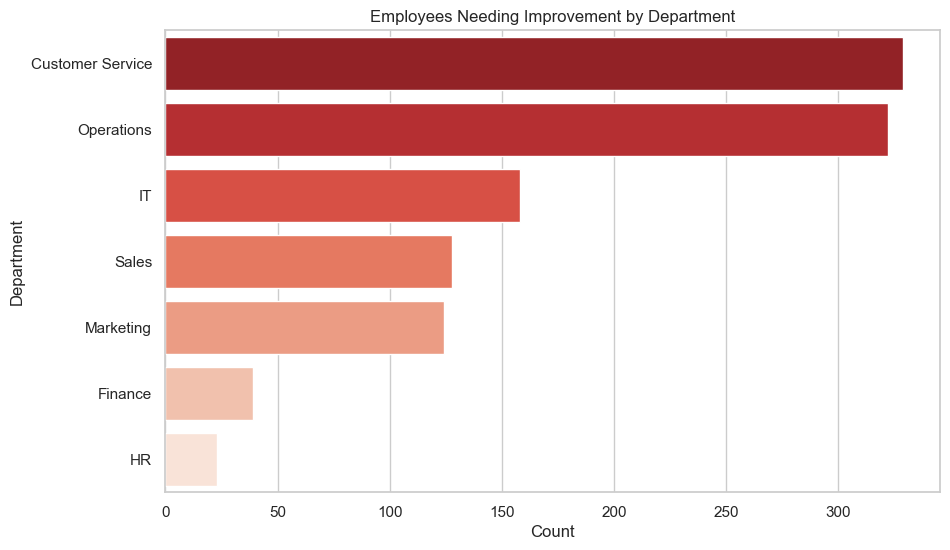

C:\Users\SIGMA\AppData\Local\Temp\ipykernel_3668\671072340.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='job_title', data=needs_improve, palette='Reds_r', order=needs_improve['job_title'].value_counts().index)


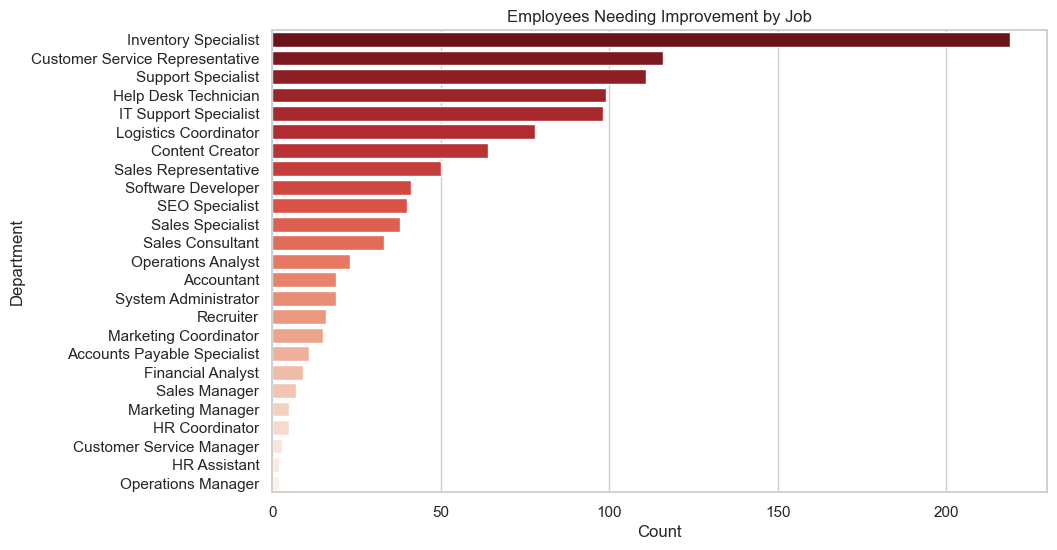

C:\Users\SIGMA\AppData\Local\Temp\ipykernel_3668\671072340.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='gender', data=needs_improve, palette='Reds_r', order=needs_improve['gender'].value_counts().index)


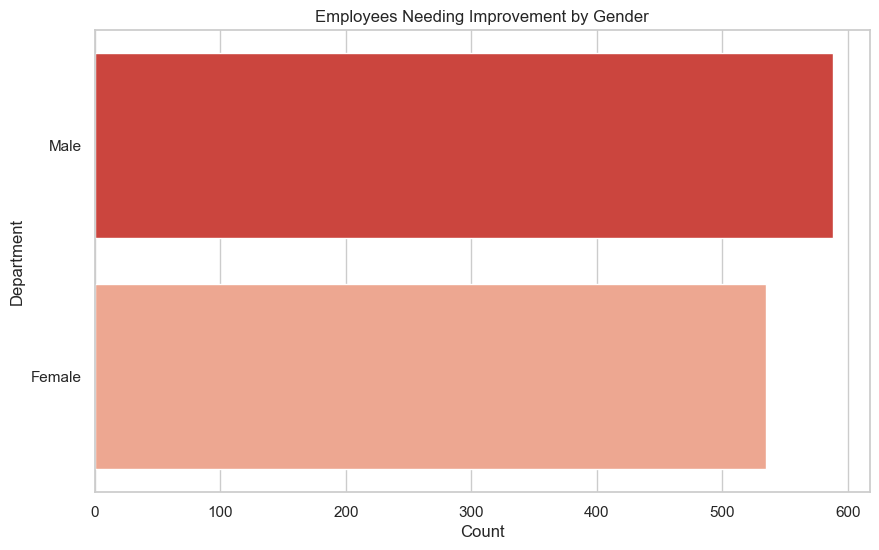

In [36]:
## by department
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.countplot(y='department', data=needs_improve, palette='Reds_r', order=needs_improve['department'].value_counts().index)
plt.title("Employees Needing Improvement by Department")
plt.xlabel("Count")
plt.ylabel("Department")
plt.show()
## by job
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.countplot(y='job_title', data=needs_improve, palette='Reds_r', order=needs_improve['job_title'].value_counts().index)
plt.title("Employees Needing Improvement by Job")
plt.xlabel("Count")
plt.ylabel("Department")
plt.show()

## by gebder
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.countplot(y='gender', data=needs_improve, palette='Reds_r', order=needs_improve['gender'].value_counts().index)
plt.title("Employees Needing Improvement by Gender")
plt.xlabel("Count")
plt.ylabel("Department")
plt.show()

In [37]:
print(f"number of total jobs: {df['job_title'].nunique()}")
df.job_title.value_counts()

number of total jobs: 28


job_title
Logistics Coordinator              1061
Inventory Specialist               1044
Sales Representative                740
Software Developer                  627
Support Specialist                  608
Sales Specialist                    565
Operations Analyst                  557
Customer Service Representative     503
Help Desk Technician                488
Sales Consultant                    478
IT Support Specialist               447
Content Creator                     308
System Administrator                280
Marketing Coordinator               206
SEO Specialist                      175
Accountant                          173
Financial Analyst                   161
Accounts Payable Specialist         109
Recruiter                            85
Customer Service Manager             74
Operations Manager                   56
HR Coordinator                       56
Sales Manager                        52
HR Assistant                         30
Marketing Manager             

In [38]:
df.columns

Index(['employee_id', 'gender', 'state', 'city', 'education_level',
       'birthdate', 'hiredate', 'termdate', 'department', 'job_title',
       'salary', 'performance_rating', 'full_name', 'status', 'age'],
      dtype='object')

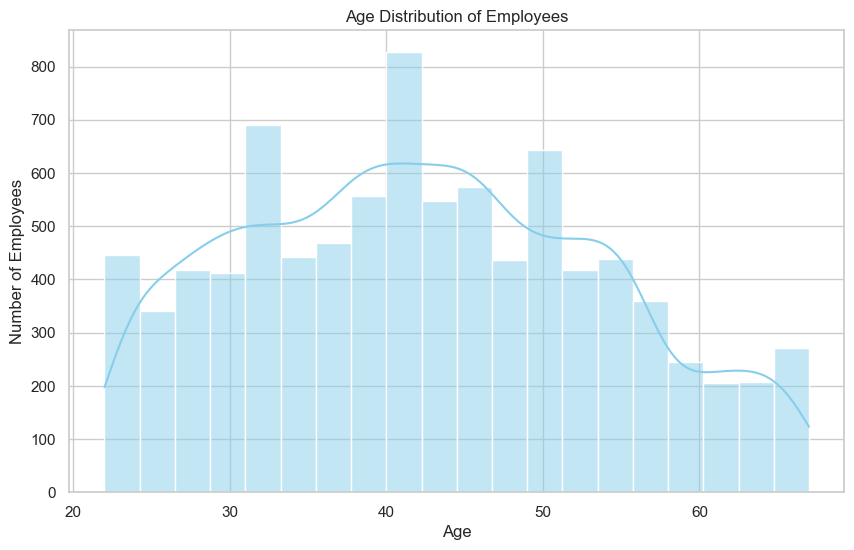

In [39]:
plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.show()

C:\Users\SIGMA\AppData\Local\Temp\ipykernel_3668\2765942778.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_salary_age = (df.groupby('age_group', as_index=False)['salary'].mean())
C:\Users\SIGMA\AppData\Local\Temp\ipykernel_3668\2765942778.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


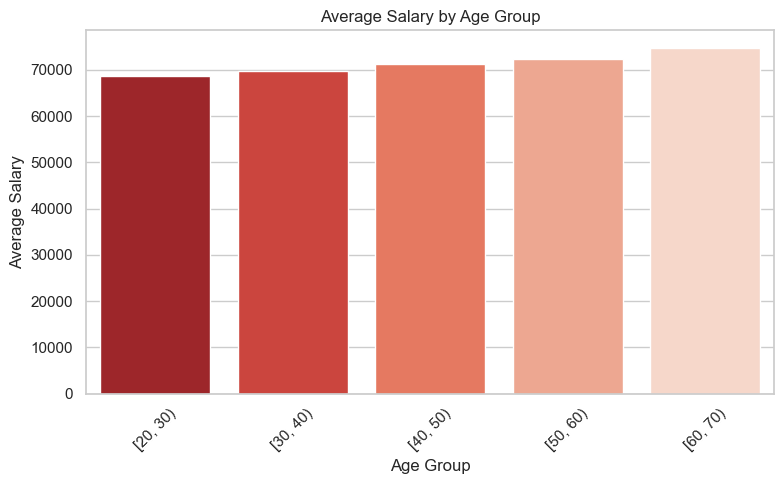

In [40]:
df['age_group'] = pd.cut(df['age'],bins=[20, 30, 40, 50, 60, 70],right=False)
avg_salary_age = (df.groupby('age_group', as_index=False)['salary'].mean())
plt.figure(figsize=(8, 5))
sns.barplot(
    data=avg_salary_age,
    x='age_group',
    y='salary',
    palette='Reds_r'
)
plt.title("Average Salary by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
df.head()

,employee_id,gender,state,city,education_level,birthdate,hiredate,termdate,department,job_title,salary,performance_rating,full_name,status,age,age_group
0,00-10001272,Female,West Virginia,Huntington,Bachelor,1975-01-11,2018-10-30,None,Customer Service,Help Desk Technician,66787.0,Satisfactory,Samuel Burgess,Active,51,"[50, 60)"
1,00-10006914,Male,Michigan,Detroit,High School,1980-09-24,2022-10-12,None,Operations,Inventory Specialist,63874.0,Needs Improvement,Ethan Case,Active,46,"[40, 50)"
2,00-10008169,Male,Michigan,Warren,Bachelor,1959-07-28,2022-11-23,None,Operations,Operations Analyst,88579.0,Good,Barbara Blair,Active,67,"[60, 70)"
3,00-10012470,Female,Michigan,Grand Rapids,Bachelor,1989-02-23,2019-10-15,None,Finance,Accountant,62543.0,Good,Amy Davidson,Active,37,"[30, 40)"
4,00-10017850,Male,New York,New York City,Bachelor,2000-09-18,2016-10-07,None,Sales,Sales Specialist,92123.0,Good,Ricky Serrano,Active,26,"[20, 30)"


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   employee_id         8950 non-null   object  
 1   gender              8950 non-null   object  
 2   state               8950 non-null   object  
 3   city                8950 non-null   object  
 4   education_level     8950 non-null   object  
 5   birthdate           8950 non-null   object  
 6   hiredate            8950 non-null   object  
 7   termdate            966 non-null    object  
 8   department          8950 non-null   object  
 9   job_title           8950 non-null   object  
 10  salary              8950 non-null   float64 
 11  performance_rating  8950 non-null   object  
 12  full_name           8950 non-null   object  
 13  status              8950 non-null   object  
 14  age                 8950 non-null   int64   
 15  age_group           8950 non-null   ca

In [43]:
df=df.drop(columns=['age_group'],axis=1)

In [44]:
df.head()

,employee_id,gender,state,city,education_level,birthdate,hiredate,termdate,department,job_title,salary,performance_rating,full_name,status,age
0,00-10001272,Female,West Virginia,Huntington,Bachelor,1975-01-11,2018-10-30,None,Customer Service,Help Desk Technician,66787.0,Satisfactory,Samuel Burgess,Active,51
1,00-10006914,Male,Michigan,Detroit,High School,1980-09-24,2022-10-12,None,Operations,Inventory Specialist,63874.0,Needs Improvement,Ethan Case,Active,46
2,00-10008169,Male,Michigan,Warren,Bachelor,1959-07-28,2022-11-23,None,Operations,Operations Analyst,88579.0,Good,Barbara Blair,Active,67
3,00-10012470,Female,Michigan,Grand Rapids,Bachelor,1989-02-23,2019-10-15,None,Finance,Accountant,62543.0,Good,Amy Davidson,Active,37
4,00-10017850,Male,New York,New York City,Bachelor,2000-09-18,2016-10-07,None,Sales,Sales Specialist,92123.0,Good,Ricky Serrano,Active,26


In [45]:
df.to_csv("hr_cleaned.csv", index=False)


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         8950 non-null   object 
 1   gender              8950 non-null   object 
 2   state               8950 non-null   object 
 3   city                8950 non-null   object 
 4   education_level     8950 non-null   object 
 5   birthdate           8950 non-null   object 
 6   hiredate            8950 non-null   object 
 7   termdate            966 non-null    object 
 8   department          8950 non-null   object 
 9   job_title           8950 non-null   object 
 10  salary              8950 non-null   float64
 11  performance_rating  8950 non-null   object 
 12  full_name           8950 non-null   object 
 13  status              8950 non-null   object 
 14  age                 8950 non-null   int64  
dtypes: float64(1), int64(1), object(13)
memory usage: 1.0+ 

In [59]:
df.groupby('job_title')['salary'].sum().sort_values(ascending = False)

job_title
Logistics Coordinator              66949972.0
Inventory Specialist               64342536.0
Software Developer                 58570593.0
Sales Representative               50894096.0
Sales Specialist                   42400528.0
Sales Consultant                   41144089.0
Operations Analyst                 41036891.0
Support Specialist                 37580725.0
Help Desk Technician               35343927.0
Customer Service Representative    30947951.0
IT Support Specialist              27530500.0
System Administrator               23930706.0
Content Creator                    18864783.0
Marketing Coordinator              14109139.0
Financial Analyst                  13911906.0
SEO Specialist                     12822539.0
Accountant                         12708115.0
Accounts Payable Specialist         6809609.0
Customer Service Manager            6273917.0
Recruiter                           5610127.0
Operations Manager                  5428481.0
Sales Manager           